In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [5]:
data = pd.read_excel("Compiled Data.xlsx")

#Provide material specs for rule of mixtures eqns (tensile strength and elasticity modulus) - physics comparison
def physics_vars(row):
    
    #general fiber material properties for tensile strength and elasticity modulus
    name = str(row['Specific Name']).upper()
    fiber = str(row["Fiber"]).lower()

    if 'IM7' in name:
        sigma_f, E_f = 820, 40
    elif 'AS4' in name:
        sigma_f, E_f = 650, 33.5
    elif 'T500' in name:
        sigma_f, E_f = 530, 34
    elif 'glass' in fiber:
        sigma_f, E_f = 500, 10.5 
    elif 'boron' in fiber:
        sigma_f, E_f = 500, 58
    elif 'carbon' in fiber:
        sigma_f, E_f = 600, 33.5

    #general resin properties for tensile strength and elasticity modulus
    resin = str(row["Matrix"]).lower()

    if 'epoxy resin' in resin:
        sigma_m, E_m  = 12, 0.50
    elif 'medium flow epoxy resin' in resin: 
        sigma_m, E_m = 13.5, 0.55
    elif 'high flow epoxy resin' in resin:
        sigma_m, E_m = 10, 0.60
    elif 'bismaleimide resin' in resin:
        sigma_m, E_m = 10.5, 0.70
    elif 'polyimide resin' in resin:
        sigma_m, E_m = 9, 0.45
    elif 'cyanate ester resin' in resin:
        sigma_m, E_m = 11, 0.50
    elif 'thermoplastic resin' in resin:
        sigma_m, E_m = 14.5, 0.55
        
    # Unidirectional = 1.0, weave = 0.5 for tensile strength
    if 'unidirectional' in str(row['Direction']).lower():
        dir = 1
    else:
        dir = 0.5
    
    Vf = 1 - row['Resin Content'] # fiber volume fraction
    Vm = row['Resin Content'] # matrix volume fraction
    
    phys_E = (Vf * E_f) + (Vm * E_m) #Young's Modulus using rule of mixtures eqn
    phys_Sigma = (dir * sigma_f * Vf) + (sigma_m * Vm) # Tensile strength using modified rule of mixtures eqn
    
    return pd.Series([phys_E, phys_Sigma])

data[['phys_E', 'phys_Sigma']] = data.apply(physics_vars, axis=1) #add predicited physics values to data table

In [65]:
features_cat = ['Composition', 'Type', 'Direction', 'Fiber', 'Matrix', 'Processing']
features_num = ['Resin Content', 'Max Cure Temp F', 'Ply Thickness', 'Void Content Max%']
targets = ['longitudinal tensile strength 75F','longitudinal tensile strength -65F','longitudinal tensile strength 250F', 
           'longitudinal tensile modulus 75F', 'longitudinal tensile modulus -65F', 'longitudinal tensile modulus 250F']

data = data.dropna(subset=targets + features_num).copy()
input_data = data[features_cat + features_num]
output_data = data[targets].values

#scale features based on each column
prep = ColumnTransformer([
    ('num', StandardScaler(), features_num),
    ('cat', OneHotEncoder(), features_cat)
])

input_data = prep.fit_transform(input_data)
input_data = np.array(input_data)

In [21]:
#Multi-Layer Perceptron
class comp_prediction(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 6) # tensile strength and modulus at each of three temps
        )
    def forward(self, x): return self.layers(x)

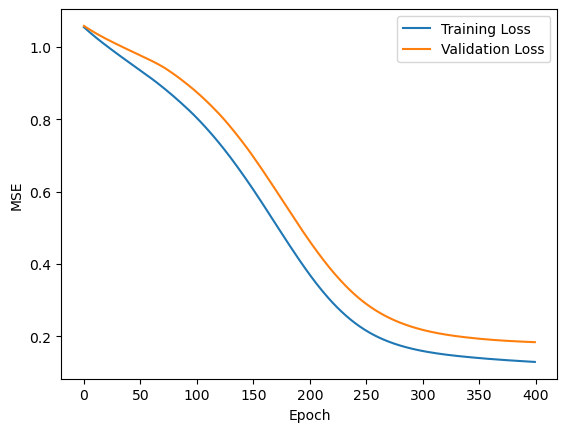

In [23]:
#Perform K-Fold Cross Validation as this is a smaller dataset
kf = KFold(n_splits=5, shuffle=True)
preds, actuals, physics = [], [], []

for fold, (train_index, test_index) in enumerate(kf.split(input_data)):
    
    #split data into training and test
    X_train, X_test = input_data[train_index], input_data[test_index]
    y_train, y_test = output_data[train_index], output_data[test_index]
    
    #scale and covert to tensors
    x_scaler = StandardScaler()
    X_train_t = torch.tensor(x_scaler.fit_transform(X_train)).float()
    X_test_t = torch.tensor(x_scaler.transform(X_test)).float()
    
    y_scaler = StandardScaler()
    y_train_t = torch.tensor(y_scaler.fit_transform(y_train)).float()
    y_test_t = torch.tensor(y_scaler.transform(y_test)).float()
    
    #initialize model
    model = comp_prediction(input_data.shape[1]) 
    opt = optim.SGD(model.parameters(), lr=0.01) #gradient descent
    error = nn.MSELoss()
    train_losses, val_losses = [], []
    
    #loop through epochs to train model
    for epoch in range(400): #increase range until low enough MSE
        model.train()
        opt.zero_grad() #clear values of prev iter
        loss = error(model(X_train_t), y_train_t) #calc difference
        loss.backward() #backpropagation
        opt.step() #weight update
 
        #check on test data for this fold
        model.eval()
        with torch.no_grad():
            val_loss = error(model(X_test_t), y_test_t)
        
        #track losses for comparison later
        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

    #Final Eval for Fold
    model.eval()
    with torch.no_grad():
        pred = model(X_test_t).numpy()
        pred_unscaled = y_scaler.inverse_transform(pred)
    
    preds.append(pred_unscaled)
    actuals.append(y_test)
    physics.append(data.iloc[test_index])

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

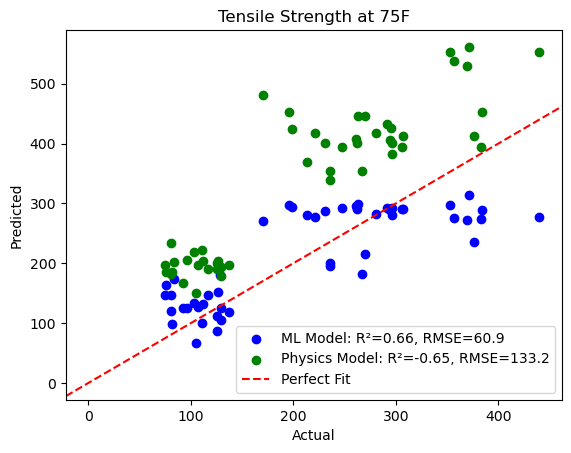

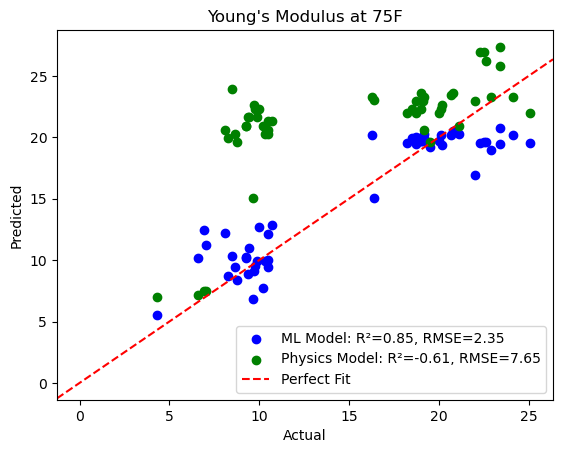

In [17]:
from sklearn.metrics import r2_score, mean_squared_error

all_a = np.vstack(actuals)
all_p = np.vstack(preds)
all_ph_df = pd.concat(physics)

#Plot Tensile Strength Comparison
#choosing 75F data since physics equations relate most to RT
a_s, p_s = all_a[:, 1], all_p[:, 1]
ph_s = all_ph_df["phys_Sigma"].values

plt.scatter(a_s, p_s, color="blue", label=f'ML Model: R²={r2_score(a_s, p_s):.2f}, RMSE={np.sqrt(mean_squared_error(a_s, p_s)):.1f}')
plt.scatter(a_s, ph_s, color="green",label=f'Physics Model: R²={r2_score(a_s, ph_s):.2f}, RMSE={np.sqrt(mean_squared_error(a_s, ph_s)):.1f}')
plt.axline((0, 0), slope=1, color="red", linestyle='--', label="Perfect Fit")

plt.title("Tensile Strength at 75F")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.show()

#Plot Tensile Modulus Comparison
#choosing 75F data since physics equations relate most to RT
a_e, p_e = all_a[:, 4], all_p[:, 4]
ph_e = all_ph_df["phys_E"].values

plt.scatter(a_e, p_e, color="blue", label=f'ML Model: R²={r2_score(a_e, p_e):.2f}, RMSE={np.sqrt(mean_squared_error(a_e, p_e)):.2f}')
plt.scatter(a_e, ph_e, color="green", label=f'Physics Model: R²={r2_score(a_e, ph_e):.2f}, RMSE={np.sqrt(mean_squared_error(a_e, ph_e)):.2f}')
plt.axline((0, 0), slope=1, color="red", linestyle='--', label="Perfect Fit")

plt.title("Young's Modulus at 75F")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.show()

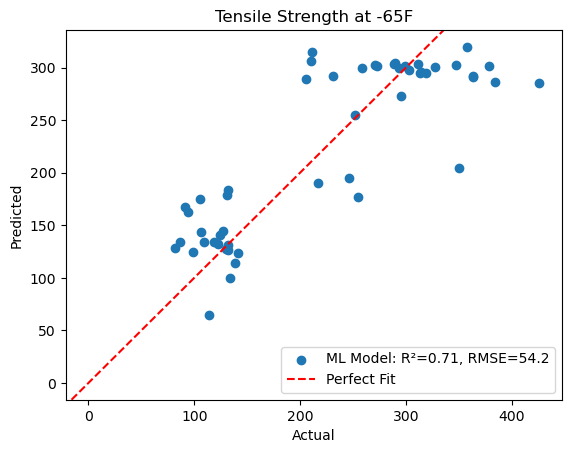

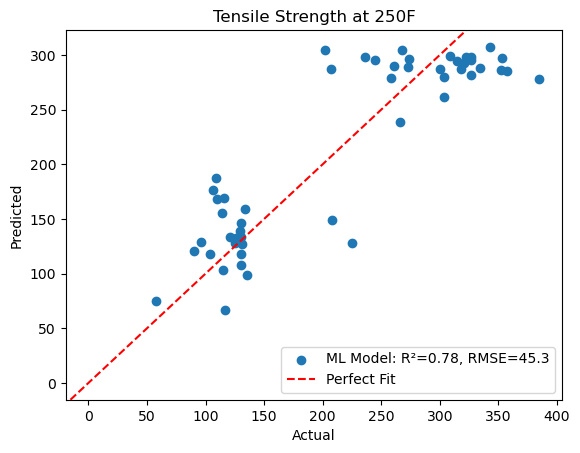

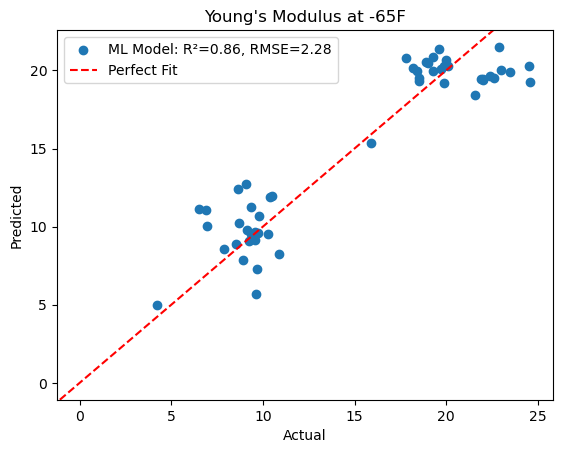

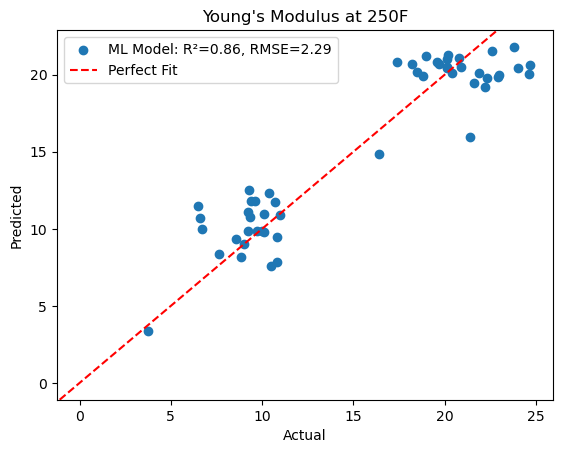

In [85]:
#Tensile Strength - '-65F'
a_s65, p_s65 = all_a[:, 0], all_p[:, 0]

plt.scatter(a_s65, p_s65, label=f'ML Model: R²={r2_score(a_s65, p_s65):.2f}, RMSE={np.sqrt(mean_squared_error(a_s65, p_s65)):.1f}')
plt.axline((0, 0), slope=1, color='red', linestyle='--', label='Perfect Fit')
plt.title("Tensile Strength at -65F")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.show()

#Tensile Strength - '250F'
a_s250, p_s250 = all_a[:, 2], all_p[:, 2]

plt.scatter(a_s250, p_s250, label=f'ML Model: R²={r2_score(a_s250, p_s250):.2f}, RMSE={np.sqrt(mean_squared_error(a_s250, p_s250)):.1f}')
plt.axline((0, 0), slope=1, color='red', linestyle='--', label='Perfect Fit')
plt.title("Tensile Strength at 250F")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.show()

#Young's Modulus '-65F'
a_e65, p_e65 = all_a[:, 3], all_p[:, 3]

plt.scatter(a_e65, p_e65, label=f'ML Model: R²={r2_score(a_e65, p_e65):.2f}, RMSE={np.sqrt(mean_squared_error(a_e65, p_e65)):.2f}')
plt.axline((0, 0), slope=1, color='red', linestyle='--', label='Perfect Fit')
plt.title("Young's Modulus at -65F")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.show()

#Young's Modulus '250F'
a_e250, p_e250 = all_a[:, 5], all_p[:, 5]

plt.scatter(a_e250, p_e250, label=f'ML Model: R²={r2_score(a_e250, p_e250):.2f}, RMSE={np.sqrt(mean_squared_error(a_e250, p_e250)):.2f}')
plt.axline((0, 0), slope=1, color='red', linestyle='--', label='Perfect Fit')
plt.title("Young's Modulus at 250F")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.show()

In [105]:
#Create function that allows entry of specific composite material properties and gives strength/elasticity prediciton for all 6 temps

def predict_comp(material_prop):
    # convert dict to dataframe
    comp_input_data = pd.DataFrame([material_prop])
    # transform data using prep from training code
    comp_input_data = prep.transform(comp_input_data)
    #convert to pytorch tensor
    comp_input_tensor = torch.tensor(comp_input_data).float()

    #Eval model
    model.eval()
    with torch.no_grad():
        scaled_pred = model(comp_input_tensor).numpy()
    
    final_pred = y_scaler.inverse_transform(scaled_pred)

    return final_pred

In [121]:
# Define random composite properties and check predicted values
material_prop = {
    'Composition': 'Carbon-Epoxy Prepreg',
    'Type': 'Tape',
    'Direction': 'Unidirectional',
    'Fiber': 'carbon-PAN',
    'Matrix': 'high flow epoxy resin',
    'Processing': 'Autoclave',
    'Resin Content': 0.32,
    'Max Cure Temp F': 350,
    'Ply Thickness': 0.0055,
    'Void Content Max%': 0.05
}

predict_comp(material_prop)

array([[292.80197 , 284.21063 , 294.62314 ,  20.527712,  20.231884,
         20.873741]], dtype=float32)

In [137]:
#use prediction function to trend how manufacturing parameters(void content and cure temp) effect final material properties

#Redefine composite properties without void and max cure temp
material_prop = {
    'Composition': 'Carbon-Epoxy Prepreg',
    'Type': 'Tape',
    'Direction': 'Unidirectional',
    'Fiber': 'carbon-PAN',
    'Matrix': 'high flow epoxy resin',
    'Processing': 'Autoclave',
    'Resin Content': 0.32,
    'Ply Thickness': 0.0055,
}

#varying void %
void_range = np.linspace(0, 10, 10)
void_results = []

for v in void_range:
    mat = material_prop.copy()
    mat['Max Cure Temp F'] = 350.0 # Holding temp constant at previously defined max cure temp value
    mat['Void Content Max%'] = v
    preds = predict_comp(mat)
    void_results.append(preds)
void_results = np.vstack(void_results)

#varying max cure temp
cure_range = np.linspace(200, 450, 10)
cure_results = []

for c in cure_range:
    mat = material_prop.copy()
    mat['Void Content Max%'] = 0.05 # Holding void % constant at previously defined void %
    mat['Max Cure Temp F'] = c
    preds = predict_comp(mat)
    cure_results.append(preds)
cure_results = np.vstack(cure_results)

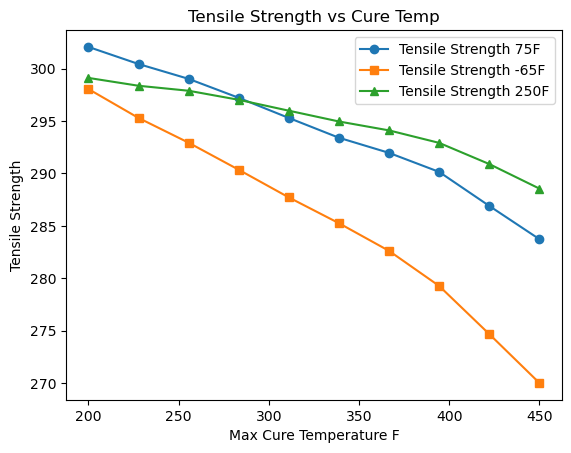

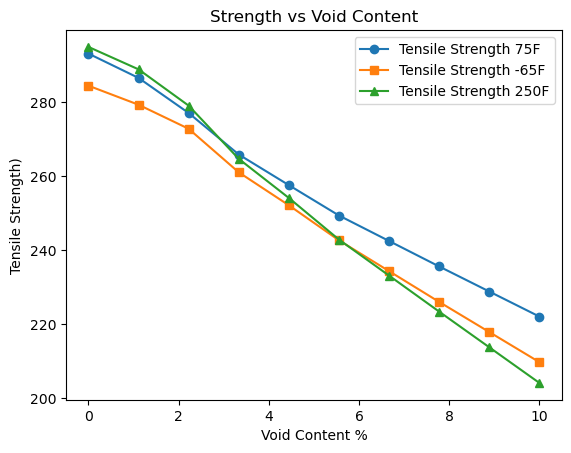

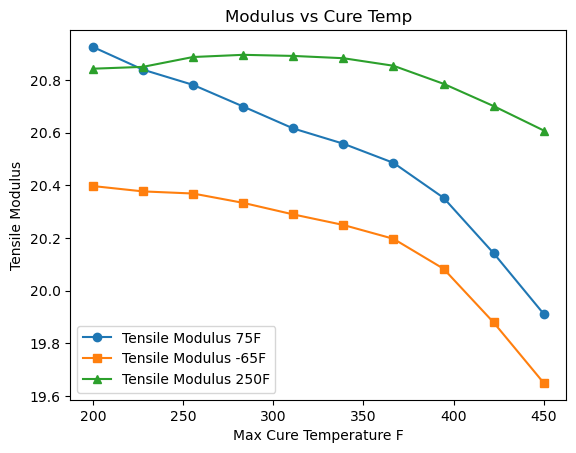

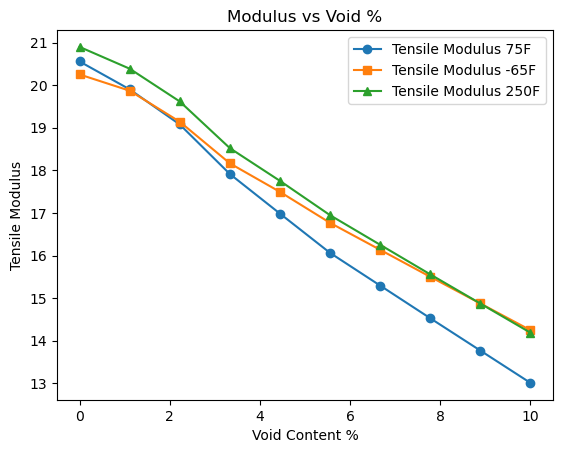

In [145]:
#Plots for void and cure temp effects

# Cure Temp vs Tensile Strength
plt.plot(cure_range, cure_results[:, 0], label='Tensile Strength 75F', marker='o')
plt.plot(cure_range, cure_results[:, 1], label='Tensile Strength -65F', marker='s')
plt.plot(cure_range, cure_results[:, 2], label='Tensile Strength 250F', marker='^')
plt.title('Tensile Strength vs Cure Temp')
plt.xlabel('Max Cure Temperature F')
plt.ylabel('Tensile Strength')
plt.legend()
plt.show()

# Void % vs Strength
plt.plot(void_range, void_results[:, 0], label='Tensile Strength 75F', marker='o')
plt.plot(void_range, void_results[:, 1], label='Tensile Strength -65F', marker='s')
plt.plot(void_range, void_results[:, 2], label='Tensile Strength 250F', marker='^')
plt.title('Strength vs Void Content')
plt.xlabel('Void Content %')
plt.ylabel('Tensile Strength)')
plt.legend()
plt.show()

# Cure Temp vs Modulus
plt.plot(cure_range, cure_results[:, 3], label='Tensile Modulus 75F', marker='o')
plt.plot(cure_range, cure_results[:, 4], label='Tensile Modulus -65F', marker='s')
plt.plot(cure_range, cure_results[:, 5], label='Tensile Modulus 250F', marker='^')
plt.title('Modulus vs Cure Temp')
plt.xlabel('Max Cure Temperature F')
plt.ylabel('Tensile Modulus')
plt.legend()
plt.show()

# Void % vs Modulus
plt.plot(void_range, void_results[:, 3], label='Tensile Modulus 75F', marker='o')
plt.plot(void_range, void_results[:, 4], label='Tensile Modulus -65F', marker='s')
plt.plot(void_range, void_results[:, 5], label='Tensile Modulus 250F', marker='^')
plt.title('Modulus vs Void %')
plt.xlabel('Void Content %')
plt.ylabel('Tensile Modulus')
plt.legend()
plt.show()